# Real-Time CV Object Tracking - YOLO26 Local Live

Run this end-to-end to analyze **live video** with the YOLO26-m detector on your own machine.

**What you get, top-to-bottom:**
- Setup: dependency check, then load the YOLO26-m detector.
- Camera picker: pick ONE source (curated public HLS, custom URL, or your own uploaded MP4/MKV).
- Sections 1-6: single-frame check, footfall time series, anomalies, dwell tracking, appearance re-ID.
- Section 7: **the live dashboard**, embedded inline, showing the picked source full-width.
- Sections 8-10: business score, multi-source ranking, accuracy calibration.

The dashboard supports 10 analysis layers on the tile itself: paths / pose / gestures / body / faces / line / loiter / parking / plates / heat. Only one layer runs at a time (operator constraint).

**Supported source types (public streaming and local file only):**
- Direct HLS (`.m3u8`) - Skylinewebcams, custom
- webcamera24.com pages
- skylinewebcams.com pages
- Your own uploaded MP4/MKV files (upload button in the dashboard header)

**Prereqs:** Python 3.10+, `pip install -r src/requirements.txt`, run this notebook from the repo root.

### Public HLS stream reality

Public live cameras are exposed as HLS (`.m3u8`) manifests. Most are reachable from any network with an open connection to the origin CDN; a few (municipal ones behind CDNs) require specific headers - the code handles those via a small pre-fetch helper. If a picked camera fails to open, try another from the catalog or upload a local MP4/MKV instead.

## 0. Setup

In [1]:
# Setup: verify every Python library the notebook needs (install what's
# missing), then download every optional model weight to this machine.
# Safe to re-run — anything already installed / already-on-disk is skipped.
# Nothing binary is checked into git — .gitignore excludes *.pt, *.onnx,
# *.pb and *_openvino_model/ so every downloaded weight lands OUTSIDE
# version control by construction.
import importlib, subprocess, sys, ssl, urllib.request
from pathlib import Path

# (import_name, pip_name). Pinned only where a min version matters.
REQUIREMENTS = [
    ('cv2',            'opencv-python-headless'),
    ('numpy',          'numpy'),
    ('pandas',         'pandas'),
    ('matplotlib',     'matplotlib'),
    ('PIL',            'Pillow'),
    ('ultralytics',    'ultralytics'),
    ('ipywidgets',     'ipywidgets>=8'),
    ('urllib3',        'urllib3'),
    # 2026-08-17: easyocr enables NON-Latin plate OCR (Thai/Arabic/
    # Japanese/Chinese/etc). Without it, plates.py silently degrades
    # to Latin-only reads - fine for TR/US/EU, blind for TH plates.
    # First import downloads ~150 MB of language weights per script.
    ('easyocr',        'easyocr>=1.7'),
    # 2026-08-19: yt-dlp 2026.06.09 AND 2026.07.04 both
    # ship a broken YouTube live extractor ('No video
    # formats found' / 'The page needs to be reloaded').
    # 2025.10.14 is the last version verified working on
    # this project's live streams as of today - HARD pin
    # until an upstream release is verified. Update the
    # pin after re-testing resolve_stream on a YouTube cam.
    ('yt_dlp',         'yt-dlp==2025.10.14'),
]

def _pip_install(spec: str) -> None:
    # 2026-08-17: Jupyter's sys.stdout is an OutStream wrapper without
    # a real fileno(), so subprocess.check_call(..., stdout=sys.stdout)
    # raised io.UnsupportedOperation: fileno and killed the whole setup.
    # Capture output ourselves and re-print it so both plain-Python and
    # Jupyter runs work identically.
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', spec],
        capture_output=True, text=True, check=False)
    if r.returncode != 0:
        # Show the FULL error the user needs to see (was hidden before
        # because -q suppresses stdout even on failure).
        print(f'  pip install {spec!r} FAILED (exit {r.returncode}):')
        for line in (r.stderr or r.stdout or '').splitlines()[-20:]:
            print(f'    {line}')
        raise subprocess.CalledProcessError(r.returncode, spec)

def _version(mod) -> str:
    return getattr(mod, '__version__', getattr(mod, 'VERSION', 'unknown'))

print(f'{"import":18} {"pip package":24} status')
print('-' * 66)
missing = []
for import_name, pip_spec in REQUIREMENTS:
    try:
        m = importlib.import_module(import_name)
        print(f'{import_name:18} {pip_spec:24} OK  v{_version(m)}')
    except ImportError:
        print(f'{import_name:18} {pip_spec:24} MISSING -> installing')
        missing.append((import_name, pip_spec))

for import_name, pip_spec in missing:
    try:
        _pip_install(pip_spec)
        importlib.invalidate_caches()
        m = importlib.import_module(import_name)
        print(f'  {import_name:16} installed  v{_version(m)}')
    except Exception as _e:
        print(f'  {import_name:16} INSTALL FAILED - {type(_e).__name__}: {_e}')
        print(f'  (continuing; downstream cells will error if they need this)')

if missing:
    print()
    print('NOTE: some packages were just installed. If the next cell errors '
          'with ModuleNotFoundError, restart the kernel (Kernel -> Restart) '
          'and re-run from the top so Python picks up the new installs.')

# -----------------------------------------------------------------------
# Weight fetch — every non-ultralytics model weight the pipeline may need.
# yolo26m.pt and yolov8n-pose.pt come from ultralytics in the next cell.
# OSNet Re-ID ONNX is not fetched (no permissive direct URL); the layer
# falls back to an HSV histogram, the default already-working behaviour.
# -----------------------------------------------------------------------
_REPO = Path.cwd() if (Path.cwd() / 'src' / 'app').is_dir() else Path.cwd().parent

# (dest_relative_to_repo_root, primary_url, [fallback_urls...], description)
_FETCH_MANIFEST = [
    (
        # LPR stage 1 (plate box detector inside a vehicle crop).
        # Chain of HF fallbacks - Koushim primary (well-known), then
        # keremberke's YOLOv5 nano (search-verified: best.pt confirmed
        # in that repo), then morsetechlab's YOLOv11 (newer architecture).
        'yolov8n-plate.pt',
        'https://huggingface.co/Koushim/yolov8-license-plate-detection/resolve/main/best.pt',
        [
            'https://huggingface.co/Koushim/yolov8-license-plate-detection/resolve/main/yolov8n-plate.pt',
            'https://huggingface.co/keremberke/yolov5n-license-plate/resolve/main/best.pt',
            'https://huggingface.co/morsetechlab/yolov11-license-plate-detection/resolve/main/best.pt',
        ],
        'LPR stage 1 (plate detector, HF community, permissive)',
    ),
    (
        'plate_ocr_global.onnx',
        # fast-plate-ocr hosts weights on the ankandrew/cnn-ocr-lp repo under the
        # 'arg-plates' release tag. Primary is v2 (newest); fallbacks are v1 relu
        # and the mobile ViT global model.
        'https://github.com/ankandrew/cnn-ocr-lp/releases/download/arg-plates/cct_xs_v2_global.onnx',
        [
            'https://github.com/ankandrew/cnn-ocr-lp/releases/download/arg-plates/cct_xs_relu_v1_global.onnx',
            'https://github.com/ankandrew/cnn-ocr-lp/releases/download/arg-plates/global_mobile_vit_v2_ocr.onnx',
        ],
        'LPR stage 2 (fast-plate-ocr global model, MIT)',
    ),
    (
        # Plate super-res model. ESPCN 4x from fannymonori's TF-ESPCN
        # repo - the mirror the OpenCV dnn_superres samples themselves
        # link to. Small (~90 KB), fast, served as raw bytes on github
        # without git-lfs. Saafke's FSRCNN mirror stopped serving the
        # .pb around 2026-08 (returned a 41 KB HTML page); we switched
        # families to ESPCN and plates.load_sr_model picks the family
        # from the filename ('espcn' -> setModel). When this file is
        # missing the plates layer silently degrades to OCR on the raw
        # crop (see plates._upscale_for_ocr).
        'models/ESPCN_x4.pb',
        'https://raw.githubusercontent.com/fannymonori/TF-ESPCN/master/export/ESPCN_x4.pb',
        [
            'https://github.com/fannymonori/TF-ESPCN/raw/master/export/ESPCN_x4.pb',
        ],
        'Plate 4x super-res (fannymonori ESPCN, MIT)',
    ),
    (
        'src/data/face_detection_yunet_2023mar.onnx',
        # opencv_zoo stores its weights as git-lfs objects; the plain
        # raw.githubusercontent.com URL returns the 131-byte LFS pointer
        # file, not the real 230 KB ONNX (would silently break YuNet).
        # media.githubusercontent.com/media/ is the LFS-bypass endpoint
        # that hands back the actual binary.
        'https://media.githubusercontent.com/media/opencv/opencv_zoo/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx',
        [],
        'Face detection (opencv_zoo YuNet via git-lfs, Apache-2.0)',
    ),
    (
        # Fire + smoke detector. Four HF repos, ordered by DOWNLOAD SIZE
        # rather than architecture recency: the lightweight nano weight
        # ships first because operators on slow connections used to time
        # out downloading the 500 MB YOLOv10 checkpoint before it
        # finished. The nano's accuracy is fine for this layer because
        # FIRE_CONFIRM_TICKS=2 filters single-tick flicker downstream.
        #   1. Notacodinggeek/yolov8n-fire-smoke   (real YOLOv8n, 18.6 MB)
        #   2. leeyunjai/yolo11-firedetect (YOLO11)
        #   3. SalahALHaismawi/yolov26-fire-detection (YOLO26, matches
        #      our primary detector architecture)
        # HF is blocked from this cloud proxy so URLs are NOT probed
        # here; every operator machine on a normal network can reach
        # them. If all four fail the fire layer publishes a clean
        # "model not loaded" caption and every other layer keeps
        # working, exactly as the fire-model-missing branch already
        # handles.
        'src/yolo_fire.pt',
        'https://huggingface.co/Notacodinggeek/yolov8n-fire-smoke/resolve/main/yolov8n-fire-smoke.pt',
        [
            'https://huggingface.co/leeyunjai/yolo11-firedetect/resolve/main/best.pt',
            'https://huggingface.co/SalahALHaismawi/yolov26-fire-detection/resolve/main/best.pt',
        ],
        'Fire + smoke YOLO (community, HF, permissive)',
    ),
]

_ctx = ssl.create_default_context()  # respect system CA (works behind corp proxies)

_MIN_WEIGHT_BYTES = 50_000  # below this a download is likely an LFS pointer or error page

def _download(url: str, dest: Path, timeout: int = 90) -> int:
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (real_time_cv notebook)'})
    with urllib.request.urlopen(req, timeout=timeout, context=_ctx) as r:
        data = r.read()
    # Guard: git-lfs pointer files look like a real 200 OK but contain
    # only 130-150 bytes of text starting with 'version https://git-lfs'.
    # Trip a distinct error so the fallback URL gets a chance.
    if data[:16].startswith(b'version https://git-lfs'):
        raise ValueError('got git-lfs pointer, not the real weight file')
    # Reject HTML/text redirect and error pages served with 200 OK.
    # A real .pt / .onnx / .pb starts with binary magic (torch: 'PK'
    # zip, onnx: 0x08 protobuf, tf pb: 0x0a protobuf). An HTML/JSON/
    # XML page starts with '<', '{' or ASCII whitespace - all sub-32.
    _head = data[:8].lstrip()
    if _head and _head[:1] in (b'<', b'{'):
        raise ValueError(f'downloaded a text/HTML page ({len(data)} bytes), not a model weight')
    if len(data) < _MIN_WEIGHT_BYTES:
        raise ValueError(f'downloaded {len(data)} bytes - too small to be a real model weight')
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(data)
    return len(data)

print()
print(f'{"weight file":50} status')
print('-' * 66)
_failed = []
for rel, primary, fallbacks, desc in _FETCH_MANIFEST:
    dest = _REPO / rel
    if dest.exists() and dest.stat().st_size > 1024:
        print(f'{rel:50} OK  ({dest.stat().st_size/1024/1024:.1f} MB present)')
        continue
    last_err = None
    for i, url in enumerate([primary] + list(fallbacks)):
        label = 'primary' if i == 0 else f'fallback {i}'
        try:
            n = _download(url, dest)
            print(f'{rel:50} downloaded {n/1024/1024:.1f} MB ({label})')
            break
        except Exception as e:
            last_err = f'{type(e).__name__}: {e}'
    else:
        print(f'{rel:50} FAILED')
        _failed.append((rel, desc, last_err))

if _failed:
    print()
    print('Note: layers depending on a failed weight will show a friendly')
    print('"model not loaded" caption and be SKIPPED - every OTHER layer plus')
    print('the notebook itself still work. To fetch a failed weight manually,')
    print('see the README Model files section for source URLs.')
    for rel, desc, err in _failed:
        print(f'  ! {rel}  ({desc})')
        print(f'    last error: {(err or "<no attempt>")[:120]}')


import             pip package              status
------------------------------------------------------------------
cv2                opencv-python-headless   OK  v4.13.0
numpy              numpy                    OK  v2.3.5
pandas             pandas                   OK  v2.3.3
matplotlib         matplotlib               OK  v3.10.6
PIL                Pillow                   OK  v12.0.0
ultralytics        ultralytics              OK  v8.4.67
ipywidgets         ipywidgets>=8            OK  v8.1.7
urllib3            urllib3                  OK  v2.5.0
easyocr            easyocr>=1.7             OK  v1.7.2
yt_dlp             yt-dlp==2025.10.14       OK  vunknown

weight file                                        status
------------------------------------------------------------------
yolov8n-plate.pt                                   OK  (6.0 MB present)
plate_ocr_global.onnx                              OK  (3.2 MB present)
models/ESPCN_x4.pb                                 OK  (

In [2]:
import os, sys, time, datetime as dt
# 2026-08-17: multi-script plate OCR. plates.py composes the fast
# Latin fast-plate-ocr head with an easyocr Reader per non-Latin
# script listed here. Thai (th), Arabic (ar), Japanese (ja) all
# load lazily on first use (~150 MB RAM per script) so a Thailand
# plate that fails Latin gets tried with Thai automatically.
os.environ.setdefault('PLATE_OCR_LANGS', 'latin,th,ar,ja')
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the src/ tree so the `app` package imports regardless of whether the
# notebook is run from the project root (default layout) or from inside src/.
_src_dir = Path.cwd() / 'src' if (Path.cwd() / 'src' / 'app').is_dir() else Path.cwd()
sys.path.append(str(_src_dir))
from app.detect_core import load_model, detect_and_count, grab_frame, resolve_stream, VEHICLE_NAMES
from app.cameras import CAMERAS, active_cameras

# --- Model: the local STRONG reference detector ---------------------------
# YOLO26-x (extra-large) is the accuracy-priority variant of the 2026 YOLO
# generation: mAP50-95 on COCO is 57.5 vs 53.1 for yolo26m, at the cost of
# ~2.4x CPU tick latency. For the notebook (which runs bursts of frames on
# demand rather than a live stream) accuracy wins - the OpenVINO IR at
# src/yolo26x_openvino_model/ still keeps the tick well below one second
# per frame on i5-class laptops.
MODEL_WEIGHTS = 'yolo26x.pt'
DATA_DIR = _src_dir / 'data'; DATA_DIR.mkdir(parents=True, exist_ok=True)
model = load_model(str(_src_dir / MODEL_WEIGHTS))
print('model:', MODEL_WEIGHTS, '(local YOLO26 extra-large)')
print('cameras available:', list(active_cameras().keys()))
print('mode: single-camera live (pick one in the picker below)')

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
detect: OpenVINO engine loaded (C:\Users\OR\Downloads\לימודים\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\src\yolo26x_openvino_model) - torch fallback ready at C:\Users\OR\Downloads\לימודים\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\yolo26x.pt
detect: OpenVINO engine loaded (C:\Users\OR\Downloads\לימודים\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\src\yolo26x_openvino_model) - adapter overlay skipped (torch-only)
model: yolo26x.pt (local YOLO26 extra-large)
cameras available: ['th_sukhumvit', 'th_chaweng_hooters', 'th_nanai_road', 'th_patong_sainamyen', 'th_petchaburi_traffic', 'th_green_mango', 'th_sukhumvit_soi11', 'th_bophut_el_gaucho', 'th_chaweng_pancake', 'th_chaweng_murphys', 'konya_hukumet', 'taksim', 'taksim_yeni', 'beyazit_meydan', 'kapali_carsi', 'misir_

### Camera picker - pick ONE source

The picker lists catalog cameras (public HLS / webcamera24 / skyline / YouTube) plus any uploaded MP4/MKV files (see the dashboard's Upload button after Section 7).

**The next code cell is INTERACTIVE and picks a SINGLE camera only.** It will print a prompt and pause the notebook until you type ONE camera number and press Enter. "Run All" will stop there and wait for you — nothing runs on a random default. Multiple numbers, ranges, or comma-separated lists are rejected: this pipeline is single-source by design. For hands-off runs (CI, cron) set `NOTEBOOK_PICK=<n>` in the environment before starting Jupyter and the prompt is skipped.


In [3]:
from app.cameras import CAMERAS, active_cameras
from IPython.display import HTML, display

_cams = active_cameras()

def _flag(country):
    return {'thailand': '🇹🇭', 'turkey': '🇹🇷', 'japan': '🇯🇵', 'usa': '🇺🇸'}.get(country, '')

if not _cams:
    print('No cameras defined. Add entries to src/app/cameras.py or upload a file via the dashboard.')
else:
    # (1) Clickable HTML preview table — one row per camera with a link
    #     that opens the source page in a new tab. Verify a stream is live
    #     here BEFORE picking a number in the next cell so you never pick
    #     a broken camera by accident.
    rows = []
    for i, (cid, cam) in enumerate(_cams.items(), 1):
        country = cam.get('country', '')
        flag = _flag(country)
        kind = cam.get('kind', '?')
        name = cam.get('name', cid)
        city = cam.get('city', '')
        page = cam.get('page') or cam.get('url') or '#'
        embed = cam.get('embed') or ''
        preview = f'<a href="{page}" target="_blank" rel="noopener">open source page</a>'
        embed_link = f' &middot; <a href="{embed}" target="_blank" rel="noopener">iframe</a>' if embed else ''
        rows.append(f'<tr><td style="text-align:right;padding-right:8px">{i}</td>'
                    f'<td>{flag}</td>'
                    f'<td style="font-family:monospace;color:#555">{kind}</td>'
                    f'<td><b>{name}</b></td>'
                    f'<td style="color:#777">{city}</td>'
                    f'<td>{preview}{embed_link}</td></tr>')
    html = (
        '<div style="font-family:sans-serif;font-size:13px">'
        f'<p><b>{len(_cams)} cameras available.</b> Click <i>open source page</i> on any row to '
        'preview the stream in a new tab <b>before</b> typing its number in the picker cell below. '
        'If a camera is offline or geo-restricted from your network, pick a different one.</p>'
        '<table style="border-collapse:collapse">'
        '<thead><tr style="background:#f4f4f4">'
        '<th style="padding:4px 8px">#</th>'
        '<th style="padding:4px 8px"></th>'
        '<th style="padding:4px 8px">kind</th>'
        '<th style="padding:4px 8px">name</th>'
        '<th style="padding:4px 8px">city</th>'
        '<th style="padding:4px 8px">preview</th>'
        '</tr></thead><tbody>'
        + ''.join(rows) +
        '</tbody></table></div>'
    )
    display(HTML(html))

    # (2) Plain-text fallback / dump — copy-pasteable, visible in any
    #     frontend that doesn't render HTML (VS Code text output,
    #     nbviewer, papermill CI runs, etc.
    print(f'\n{len(_cams)} camera(s) available (plain text):')
    for i, (cid, cam) in enumerate(_cams.items(), 1):
        area = cam.get('city') or cam.get('area', '')
        print(f'  {i:2d}. [{cam.get("kind", "?"):<12}] {cam["name"]:<55}  {area}')


#,,kind,name,city,preview
1,🇹🇭,youtube,Sukhumvit Rd (Bangkok),Bangkok,open source page · iframe
2,🇹🇭,youtube,Chaweng Beach Rd (Koh Samui),Koh Samui,open source page · iframe
3,🇹🇭,youtube,Nanai Rd (Patong),Patong,open source page · iframe
4,🇹🇭,youtube,Sainamyen Rd (Patong),Patong,open source page · iframe
5,🇹🇭,youtube,Petchaburi Rd traffic (Bangkok),Bangkok,open source page · iframe
6,🇹🇭,youtube,Soi Green Mango (Chaweng),Koh Samui,open source page · iframe
7,🇹🇭,youtube,Sukhumvit Soi 11 - El Gaucho (Bangkok),Bangkok,open source page · iframe
8,🇹🇭,youtube,"El Gaucho - Fisherman's Village (Bophut, Koh Samui)",Koh Samui,open source page · iframe
9,🇹🇭,youtube,Chaweng - Pancake Man (Koh Samui),Koh Samui,open source page · iframe
10,🇹🇭,youtube,Chaweng - Murphy's Irish Pub (Koh Samui),Koh Samui,open source page · iframe



60 camera(s) available (plain text):
   1. [youtube     ] Sukhumvit Rd (Bangkok)                                   Bangkok
   2. [youtube     ] Chaweng Beach Rd (Koh Samui)                             Koh Samui
   3. [youtube     ] Nanai Rd (Patong)                                        Patong
   4. [youtube     ] Sainamyen Rd (Patong)                                    Patong
   5. [youtube     ] Petchaburi Rd traffic (Bangkok)                          Bangkok
   6. [youtube     ] Soi Green Mango (Chaweng)                                Koh Samui
   7. [youtube     ] Sukhumvit Soi 11 - El Gaucho (Bangkok)                   Bangkok
   8. [youtube     ] El Gaucho - Fisherman's Village (Bophut, Koh Samui)      Koh Samui
   9. [youtube     ] Chaweng - Pancake Man (Koh Samui)                        Koh Samui
  10. [youtube     ] Chaweng - Murphy's Irish Pub (Koh Samui)                 Koh Samui
  11. [hls         ] Konya - Hukumet Meydani / Sarraflar Yeralti Carsisi      Konya
  12. [hls

In [4]:
# INTERACTIVE PICKER — this cell PAUSES the notebook and asks you which
# ONE camera to analyse. Type ONE number from the list above and press
# Enter. The picker selects a SINGLE camera only — the notebook runs
# end-to-end on that one source.
#
# For hands-off runs (CI, headless), set the NOTEBOOK_PICK environment
# variable to the camera number BEFORE launching Jupyter and the prompt
# is skipped.
import os

_all = list(active_cameras().items())
if not _all:
    raise RuntimeError("No cameras. Add to cameras.py or upload via dashboard.")

_env_pick = os.environ.get('NOTEBOOK_PICK')
if _env_pick:
    _raw = _env_pick.strip()
    print(f'NOTEBOOK_PICK={_raw} (from environment - skipping the interactive prompt)')
else:
    print(f'{len(_all)} camera(s) available (see list above).')
    _raw = input(f'>>> Pick ONE camera number (1-{len(_all)}) and press Enter: ').strip()

if not _raw:
    raise RuntimeError(
        'No camera picked. Type ONE number in the input prompt above and re-run '
        'this cell, or set NOTEBOOK_PICK=<n> in the environment for hands-off runs.'
    )
# Guard against operators who paste multiple numbers or a range: the
# picker is single-camera only, by design.
if any(sep in _raw for sep in (',', ' ', '-', ';', '/')):
    raise ValueError(
        f'Got {_raw!r}. The picker selects ONE camera only — pass a single '
        f'number between 1 and {len(_all)}. If you want to compare multiple '
        f'cameras, re-run the notebook once per camera.'
    )
try:
    PICK = int(_raw)
except ValueError:
    raise ValueError(f'Not a number: {_raw!r}. Type just the digit shown next to your camera above.')

if not (1 <= PICK <= len(_all)):
    raise IndexError(f'PICK must be between 1 and {len(_all)} (got {PICK})')

SELECTED_CAM_ID, SELECTED_CAM = _all[PICK - 1]
SELECTED_CAMS = [SELECTED_CAM_ID]  # list-of-one for downstream cells; SINGLE camera only
SELECTED_CAMS_APPLIED = True
print(f'Selected #{PICK}: {SELECTED_CAM_ID} - {SELECTED_CAM["name"]}')

60 camera(s) available (see list above).


>>> Pick ONE camera number (1-60) and press Enter:  8


Selected #8: th_bophut_el_gaucho - El Gaucho - Fisherman's Village (Bophut, Koh Samui)


### Picked camera

A quick one-line confirmation of which camera the rest of the notebook will analyze.

In [5]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    # No interactive picker choice was applied. Instead of throwing an
    # opaque exception that pauses the notebook, print a clear warning
    # and default to the first camera in the catalog so the operator
    # can Restart & Run All top-to-bottom without hand-clicking every
    # cell. The verify cell above STILL lets them pick a different one
    # and re-run from there.
    try:
        _default_id = next(iter(CAMERAS))
    except (NameError, StopIteration):
        raise RuntimeError('CAMERAS catalog not loaded - run the earlier setup cells first')
    SELECTED_CAM_ID = _default_id
    SELECTED_CAM = CAMERAS[_default_id]
    SELECTED_CAMS = [_default_id]
    SELECTED_CAMS_APPLIED = True
    print(f'NOTE: no picker choice applied - defaulting to {_default_id} '
          f'("{SELECTED_CAM["name"]}"). To pick a different camera, run '
          f'the interactive picker cell above and re-run this cell.')
print(f'Notebook will analyze: {SELECTED_CAM_ID} - {SELECTED_CAM["name"]}')

Notebook will analyze: th_bophut_el_gaucho - El Gaucho - Fisherman's Village (Bophut, Koh Samui)


## 1. Pick a camera

The catalog lives in `app/cameras.py`. Each entry declares a `kind` (`hls`, `skyline`, `webcamera24`, or `local_file`). `resolve_stream(cam)` turns the entry into an openable HLS URL and caches the result until any embedded token expires:

- `hls` - the URL is used directly.
- `skyline` - the tokenized `hd-auth.skylinewebcams.com` playlist, scraped live.
- `webcamera24` - the embedded stream on the webcamera24 page.
- `local_file` - a path to an MP4/MKV/MOV/AVI/WEBM you uploaded via the dashboard.

`SELECTED_CAMS[0]` (a list-of-one from the numeric picker) is the one this section inspects.

In [6]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    # No interactive picker choice was applied. Instead of throwing an
    # opaque exception that pauses the notebook, print a clear warning
    # and default to the first camera in the catalog so the operator
    # can Restart & Run All top-to-bottom without hand-clicking every
    # cell. The verify cell above STILL lets them pick a different one
    # and re-run from there.
    try:
        _default_id = next(iter(CAMERAS))
    except (NameError, StopIteration):
        raise RuntimeError('CAMERAS catalog not loaded - run the earlier setup cells first')
    SELECTED_CAM_ID = _default_id
    SELECTED_CAM = CAMERAS[_default_id]
    SELECTED_CAMS = [_default_id]
    SELECTED_CAMS_APPLIED = True
    print(f'NOTE: no picker choice applied - defaulting to {_default_id} '
          f'("{SELECTED_CAM["name"]}"). To pick a different camera, run '
          f'the interactive picker cell above and re-run this cell.')

SELECTED_CAM = CAMERAS[SELECTED_CAM_ID]
CAM_ID = SELECTED_CAM_ID
cam = SELECTED_CAM
stream_url = resolve_stream(SELECTED_CAM)
print(f'{SELECTED_CAM["name"]} -> {stream_url}')


El Gaucho - Fisherman's Village (Bophut, Koh Samui) -> https://manifest.googlevideo.com/api/manifest/hls_playlist/expire/1787344134/ei/pmCIaugG9IS90g-ekKXwBw/ip/2a06:c701:9a1c:1300:d85:1c23:5fc1:bbe2/id/FyFAqPHBKiQ.4/itag/96/source/yt_live_broadcast/requiressl/yes/ratebypass/yes/live/1/sgoap/gir%3Dyes%3Bitag%3D140/sgovp/gir%3Dyes%3Bitag%3D137/rqh/1/hls_chunk_host/rr4---sn-pujapa-ua8e.googlevideo.com/xpc/EgVo2aDSNQ%3D%3D/playlist_duration/30/manifest_duration/30/bui/AR3QkAlvBoFvGgJ8wAiU4IaDHa9pXPFUqchLI8dRzd3YrLb0gzAxObr7WtRoNuY8dFGspDbNpFOKEGXd/spc/KBGBcr0raJUEEzZkZlVAHcHe3y4wrMh4zS51so2FzSURqi5sPuB3hfB6hd90l8QE/vprv/1/reg/0/playlist_type/DVR/initcwndbps/3090000/met/1787322534,/mh/C-/mm/44/mn/sn-pujapa-ua8e/ms/lva/mv/m/mvi/4/pl/48/rms/lva,lva/dover/11/pacing/0/keepalive/yes/fexp/51565115/mt/1787322043/sparams/expire,ei,ip,id,itag,source,requiressl,ratebypass,live,sgoap,sgovp,rqh,xpc,playlist_duration,manifest_duration,bui,spc,vprv,reg,playlist_type/sig/AE0s2JYwRgIhAOx_TuM6gB7rPc7K0Mh5X

## 2. Single-frame check

Confirm the stream decodes and YOLO sees the crowd before collecting anything.

frame shape: (1080, 1920, 3)
Loading C:\Users\OR\Downloads\\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\src\yolo26x_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...
counts: {'person': 9, 'bicycle': 0, 'car': 0, 'motorcycle': 1, 'bus': 0, 'train': 0, 'truck': 1, 'animal': 0, 'vehicles': 2}


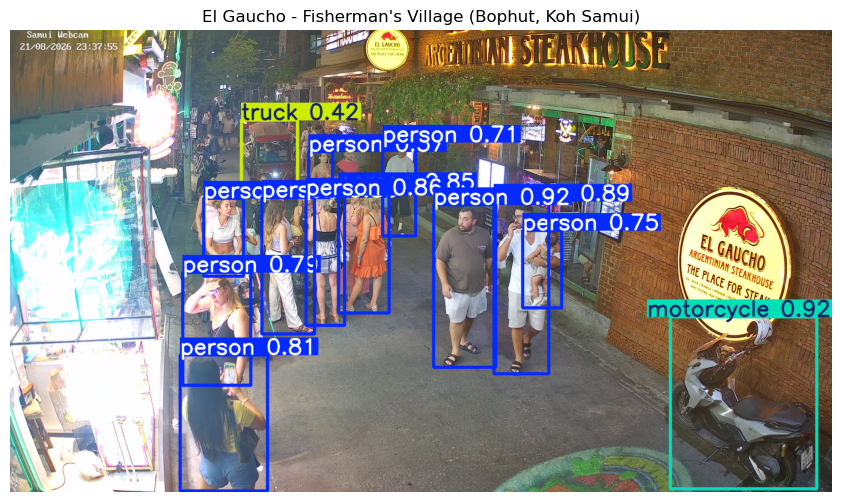

In [7]:
frame = grab_frame(stream_url)
if frame is None:
    print(f"WARN: {cam['name']} returned no frame (stream down or unreachable).")
    print('Pick another camera: change PICK in the numeric-picker cell above and re-run from there.')
else:
    print('frame shape:', frame.shape)
    print('counts:', detect_and_count(model, frame))

    res = model.predict(frame, conf=0.35, classes=[0,1,2,3,5,6,7], verbose=False)[0]
    plt.figure(figsize=(11, 6))
    plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.title(cam['name']); plt.show()

## 3. Footfall time series (sparse sampling)

For the **how much / when** question we don't need every frame - one sample every 15-30s is plenty and
is gentle on the server. This is the same logic the collector runs continuously.

In [8]:
def footfall_series(stream_url, cam_name, interval_s=20, duration_min=1.0):
    rows, t_end = [], time.time() + duration_min * 60
    while time.time() < t_end:
        ts = dt.datetime.now(dt.timezone.utc)
        f = grab_frame(stream_url)
        c = detect_and_count(model, f) if f is not None else {'person': np.nan, 'vehicles': np.nan}
        rows.append({'ts': ts, 'cam': cam_name, 'person': c.get('person'), 'vehicles': c.get('vehicles')})
        print(f"[{ts:%H:%M:%S}] person={c.get('person')} vehicles={c.get('vehicles')}")
        time.sleep(interval_s)
    return pd.DataFrame(rows)

# Short live-collection run. Raise duration_min for longer studies, or just leave the
# collector daemon (`python -m app.collector`) running for genuine 24/7 data.
df = footfall_series(stream_url, cam['name'], interval_s=10, duration_min=1.0)
df.to_csv(DATA_DIR / f'footfall_{CAM_ID}.csv', index=False)
df.head()

[16:38:29] person=9 vehicles=2
[16:38:47] person=8 vehicles=1
[16:39:01] person=7 vehicles=3
[16:39:15] person=5 vehicles=3


,ts,cam,person,vehicles
0,2026-08-21 16:38:29.358169+00:00,"El Gaucho - Fisherman's Village (Bophut, Koh S...",9,2
1,2026-08-21 16:38:47.336771+00:00,"El Gaucho - Fisherman's Village (Bophut, Koh S...",8,1
2,2026-08-21 16:39:01.529793+00:00,"El Gaucho - Fisherman's Village (Bophut, Koh S...",7,3
3,2026-08-21 16:39:15.295148+00:00,"El Gaucho - Fisherman's Village (Bophut, Koh S...",5,3


## 4. Anomalies + peak-hour profile

**Anomaly = rolling z-score > 3.5** on the footfall series: a sudden surge (event/promotion/protest) or an
unusual drop (closure/weather). Peak-hour profile tells you *when* the commercial window is.

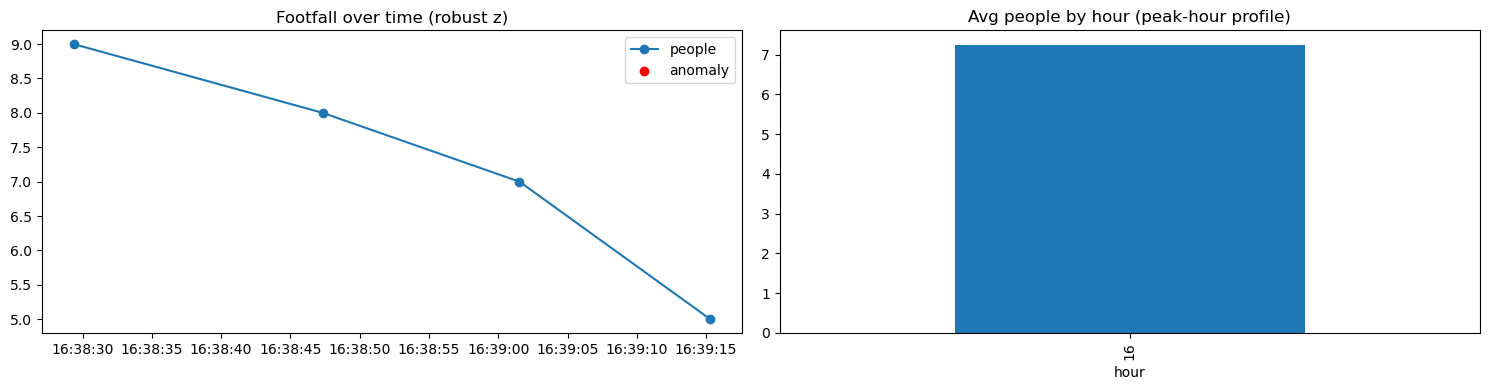

In [9]:
def flag_anomalies(s, window=12, z=3.5, min_delta=3):
    """Robust rolling z: median + MAD (x1.4826), the same statistic the local run
    collector uses. Outliers already inside the window inflate a mean/std
    baseline and mask the next event; a median/MAD baseline barely moves."""
    med = s.rolling(window, min_periods=4).median()
    mad = (s - med).abs().rolling(window, min_periods=4).median() * 1.4826
    spread = mad.clip(lower=1.0)   # counts are integers; floor the spread
    robust_z = (s - med) / spread
    return (robust_z.abs() > z) & ((s - med).abs() >= min_delta)

df['ts'] = pd.to_datetime(df['ts'])
df['anomaly'] = flag_anomalies(df['person'])

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(df['ts'], df['person'], marker='o', label='people')
an = df[df['anomaly'] == True]
ax[0].scatter(an['ts'], an['person'], color='red', zorder=5, label='anomaly')
ax[0].set_title('Footfall over time (robust z)'); ax[0].legend()

df['hour'] = df['ts'].dt.hour
df.groupby('hour')['person'].mean().plot(kind='bar', ax=ax[1])
ax[1].set_title('Avg people by hour (peak-hour profile)')
plt.tight_layout(); plt.show()

## 5. Dwell-time / prolonged stops (tracking)

"How long does a person or vehicle stay in front of the camera?" needs **object tracking** (stable IDs
across frames), which only works on *consecutive* frames - so here we take a short **dense burst**
(a few fps for ~60s) instead of sparse sampling. Ultralytics `model.track()` (ByteTrack) gives each
object an id; we accumulate how many frames each id is seen and how little it moves.

- **Long dwell + low movement** = lingering: window-shopping / a queue / a parked vehicle.
- High share of *lingering* people is a strong **commercial-quality** signal (people stop, not just pass).

In [10]:
from app.detect_core import iter_frames, NAME_BY_ID

def dwell_analysis(stream_url, seconds=30, target_fps=3, conf=0.35):
    """Dense burst with tracking. Returns per-track dwell seconds + movement.

    iter_frames handles header-required hosts (tvkur, IBB, skylinewebcams) by
    downloading the latest segments with the right Referer/Origin and decoding
    locally, since cv2.VideoCapture(url) can't pass headers on Windows.
    """
    frames_seen = defaultdict(int)
    centroids = defaultdict(list)
    track_cls = {}
    n_frames = int(seconds * target_fps)
    # Sample at ~target_fps: source streams run ~25 fps, so skip frames
    # with `stride` - reading consecutive frames would compress the
    # whole window into ~n/25 seconds and overstate dwell ~8x.
    stride = max(1, round(25 / target_fps))
    for frame in iter_frames(stream_url, max_frames=n_frames, stride=stride):
        r = model.track(frame, persist=True, conf=conf, classes=[0,1,2,3,5,6,7],
                        tracker='bytetrack.yaml', verbose=False)[0]
        if r.boxes.id is not None:
            for box, tid, cl in zip(r.boxes.xywh.cpu().numpy(),
                                    r.boxes.id.int().cpu().tolist(),
                                    r.boxes.cls.int().cpu().tolist()):
                frames_seen[tid] += 1
                centroids[tid].append((float(box[0]), float(box[1])))
                track_cls[tid] = cl

    rows = []
    for tid, n in frames_seen.items():
        pts = np.array(centroids[tid])
        movement = float(np.linalg.norm(pts.max(0) - pts.min(0))) if len(pts) > 1 else 0.0
        rows.append({'track_id': tid,
                     'class': NAME_BY_ID.get(track_cls[tid], str(track_cls[tid])),
                     'dwell_s': round(n / target_fps, 1),
                     'movement_px': round(movement, 1)})
    return pd.DataFrame(rows).sort_values('dwell_s', ascending=False) if rows else pd.DataFrame(
        columns=['track_id','class','dwell_s','movement_px'])

dwell = dwell_analysis(stream_url, seconds=30, target_fps=3, conf=0.25)
dwell.head(15)

,track_id,class,dwell_s,movement_px
3,4,person,20.0,158.6
2,3,person,19.0,59.4
1,2,person,17.3,148.5
17,43,person,16.7,45.1
7,8,car,16.3,17.8
10,12,person,16.0,112.1
8,9,person,15.3,16.8
20,46,person,13.3,458.7
4,5,motorcycle,13.3,34.6
5,6,person,12.7,19.8


In [11]:
# Flag prolonged stationary objects: long dwell AND little movement.
PERSON_DWELL_S, VEHICLE_DWELL_S, MAX_MOVE_PX = 25, 40, 60
if not dwell.empty:
    is_person = dwell['class'] == 'person'
    stationary = dwell[((is_person & (dwell['dwell_s'] >= PERSON_DWELL_S)) |
                        (~is_person & (dwell['dwell_s'] >= VEHICLE_DWELL_S)))
                       & (dwell['movement_px'] <= MAX_MOVE_PX)]
    print(f"Prolonged stops detected: {len(stationary)}")
    display(stationary)
    linger_rate = (is_person & (dwell['dwell_s'] >= PERSON_DWELL_S)).sum() / max(1, is_person.sum())
    print(f"Linger rate (people who stayed >= {PERSON_DWELL_S}s): {linger_rate:.0%}")

Prolonged stops detected: 0


,track_id,class,dwell_s,movement_px


Linger rate (people who stayed >= 25s): 0%


## 5b. Re-identification - "have I seen this person before?"

The detection counts above tell you *how many* people are visible at any moment, but they
double-count anyone who lingers in front of the camera. To answer questions like *"how many
unique customers walked by today?"* or *"is that the same delivery van I saw yesterday?"*
we need **re-identification**: a persistent identity attached to each person/vehicle that
survives across frames, bursts and days.

The implementation is in `app/reid.py`:

1. For each YOLO detection, crop the bounding box.
2. Build a *masked* HSV color histogram (8x8x8 bins, V<30 pixels ignored - kills the
 sodium-yellow night cast on the your picked camera square) plus aspect ratio + normalized area.
3. L2-normalize -> 514-dim appearance vector.
4. Compare to every entity of the same class already in `data/reid.db` via cosine
 similarity. If the best match is >= `threshold` (default 0.92) we update its
 `sightings` and `last_seen`; otherwise we register a new entity.

This is a **demo-grade signature**. It works well in daylight (different clothing colors
give clearly different histograms). It produces false matches at night when the whole
scene is yellow-tinted - swap `embed_crop()` for an OSNet/torchreid forward pass for
production-grade re-ID; the SQLite registry around it stays the same.

In [12]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    # No interactive picker choice was applied. Instead of throwing an
    # opaque exception that pauses the notebook, print a clear warning
    # and default to the first camera in the catalog so the operator
    # can Restart & Run All top-to-bottom without hand-clicking every
    # cell. The verify cell above STILL lets them pick a different one
    # and re-run from there.
    try:
        _default_id = next(iter(CAMERAS))
    except (NameError, StopIteration):
        raise RuntimeError('CAMERAS catalog not loaded - run the earlier setup cells first')
    SELECTED_CAM_ID = _default_id
    SELECTED_CAM = CAMERAS[_default_id]
    SELECTED_CAMS = [_default_id]
    SELECTED_CAMS_APPLIED = True
    print(f'NOTE: no picker choice applied - defaulting to {_default_id} '
          f'("{SELECTED_CAM["name"]}"). To pick a different camera, run '
          f'the interactive picker cell above and re-run this cell.')
from app.detect_core import load_model, grab_frame, detect_with_boxes, annotate
from app.reid import ReidStore
import cv2, time
import matplotlib.pyplot as plt

REID_DB = str(_src_dir / 'data' / 'reid_notebook.db')
Path(REID_DB).parent.mkdir(parents=True, exist_ok=True)

# If we're re-running the notebook (the kernel is alive), the previous ReidStore is
# still holding a SQLite connection to REID_DB. Close it before we try to delete
# the file, otherwise Windows returns PermissionError [WinError 32].
try:
    reid.close()         # noqa: F821  (reid is defined by a prior run of this cell)
except NameError:
    pass

# Fresh registry for the demo so re-runs are reproducible. If something else
# still holds the file (orphan kernel, antivirus scan), we keep the existing
# rows instead of crashing - re-identification just continues with what's there.
try:
    Path(REID_DB).unlink(missing_ok=True)
    print('reid_notebook.db cleared - fresh demo registry')
except PermissionError:
    print('reid_notebook.db is locked by another process - keeping existing rows. '
          'New entities will be merged into the existing registry; this is fine '
          'for the demo, just not a clean-room run.')

reid = ReidStore(REID_DB, threshold=0.92)

# Use the model we already loaded above; lower conf so we catch the small/distant
# distant people the wide-angle camera shows.
# CAM_ID inherits from the verify cell (SELECTED_CAMS[0]) so re-ID runs on
# the same camera as the earlier sections, not a hard-coded default.
CAM_ID = SELECTED_CAMS[0]
cam = CAMERAS[CAM_ID]
stream_url = resolve_stream(cam)   # hls / skyline / webcamera24
print('feeding re-ID from', cam['name'])

reid_notebook.db cleared - fresh demo registry
feeding re-ID from El Gaucho - Fisherman's Village (Bophut, Koh Samui)


In [13]:
# Sample N frames every `interval_s` seconds, run YOLO on each, push every detection
# through the re-ID registry. Short loop here so the notebook completes; the collector
# daemon does the real long-running version.
N_SAMPLES, INTERVAL_S, CONF = 8, 5, 0.25

rows = []
for i in range(N_SAMPLES):
    f = grab_frame(stream_url)
    if f is None:
        print(f'[{i:02d}] miss'); time.sleep(INTERVAL_S); continue
    counts, boxes = detect_with_boxes(model, f, conf=CONF)
    results = reid.update_from_frame(CAM_ID, f, boxes)
    new = sum(r.is_new for r in results)
    seen_again = len(results) - new
    rows.append({'sample': i, 'person': counts['person'], 'vehicles': counts['vehicles'],
                 'detections': len(boxes), 'new_ids': new, 'seen_again': seen_again})
    print(f'[{i:02d}] person={counts["person"]} vehicles={counts["vehicles"]} '
          f'-> new={new} seen_again={seen_again}')
    time.sleep(INTERVAL_S)

reid_df = pd.DataFrame(rows)
reid_df

[00] person=2 vehicles=2 -> new=4 seen_again=0
[01] person=1 vehicles=2 -> new=2 seen_again=1
[02] person=2 vehicles=1 -> new=3 seen_again=0
[03] person=5 vehicles=1 -> new=6 seen_again=0
[04] person=3 vehicles=1 -> new=3 seen_again=1
[05] person=1 vehicles=1 -> new=1 seen_again=1
[06] person=1 vehicles=3 -> new=3 seen_again=1
[07] person=3 vehicles=2 -> new=3 seen_again=2


,sample,person,vehicles,detections,new_ids,seen_again
0,0,2,2,4,4,0
1,1,1,2,3,2,1
2,2,2,1,3,3,0
3,3,5,1,6,6,0
4,4,3,1,4,3,1
5,5,1,1,2,1,1
6,6,1,3,4,3,1
7,7,3,2,5,3,2


In [14]:
# Roll-up: how many unique entities did we see? how many came back >=3 times?
stats = reid.stats(CAM_ID)
print('Total unique entities (this camera):', stats['total_unique'])
print('Total sightings:', stats['total_sightings'])
for cls, s in stats['per_class'].items():
    print(f"  {cls:10s}  unique={s['unique']}  sightings={s['total_sightings']}  "
          f"regulars(>=3)={s['regulars']}")

print('\nTop returning entities:')
for r in reid.top_regulars(CAM_ID, n=10):
    print(f"  #{r['entity_id']:4d}  {r['cls']:8s}  sightings={r['sightings']}  "
          f"first={r['first_seen']}  last={r['last_seen']}")

Total unique entities (this camera): 25
Total sightings: 31
  car         unique=3  sightings=4  regulars(>=3)=0
  motorcycle  unique=4  sightings=9  regulars(>=3)=1
  person      unique=18  sightings=18  regulars(>=3)=0

Top returning entities:
  #   1  motorcycle  sightings=5  first=2026-08-21T16:43:19Z  last=2026-08-21T16:44:21Z
  #   5  car       sightings=2  first=2026-08-21T16:43:28Z  last=2026-08-21T16:44:21Z
  #  10  motorcycle  sightings=2  first=2026-08-21T16:43:47Z  last=2026-08-21T16:43:55Z
  #   2  car       sightings=1  first=2026-08-21T16:43:19Z  last=2026-08-21T16:43:19Z
  #  21  car       sightings=1  first=2026-08-21T16:44:12Z  last=2026-08-21T16:44:12Z
  #   7  motorcycle  sightings=1  first=2026-08-21T16:43:38Z  last=2026-08-21T16:43:38Z
  #  22  motorcycle  sightings=1  first=2026-08-21T16:44:12Z  last=2026-08-21T16:44:12Z
  #   3  person    sightings=1  first=2026-08-21T16:43:19Z  last=2026-08-21T16:43:19Z
  #   4  person    sightings=1  first=2026-08-21T16:43:19Z

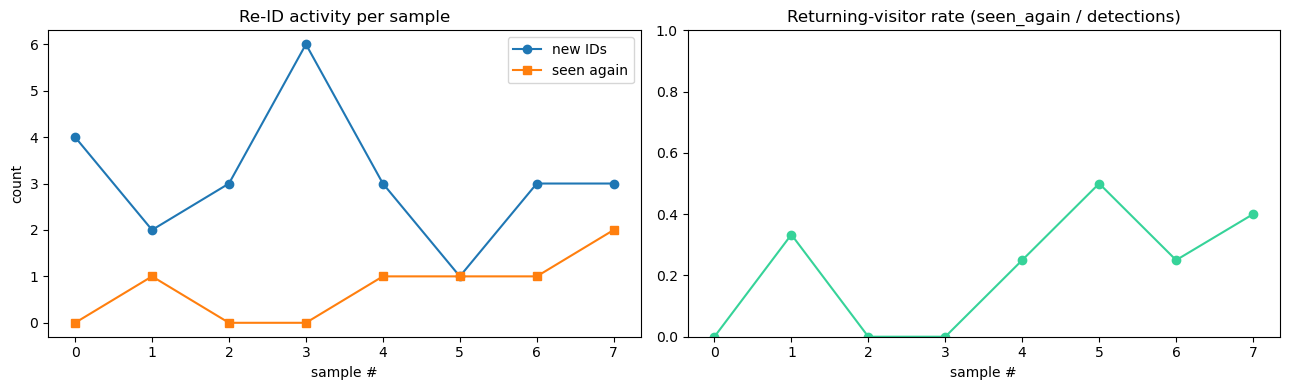

In [15]:
# Visual: returning-visitor curve - what fraction of detections are 'seen again' over time?
if len(reid_df) >= 3:
    reid_df = reid_df.copy()
    reid_df['returning_rate'] = (reid_df['seen_again'] /
                                 reid_df['detections'].replace(0, np.nan))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(reid_df['sample'], reid_df['new_ids'], marker='o', label='new IDs')
    ax[0].plot(reid_df['sample'], reid_df['seen_again'], marker='s', label='seen again')
    ax[0].set_title('Re-ID activity per sample')
    ax[0].set_xlabel('sample #'); ax[0].set_ylabel('count'); ax[0].legend()

    ax[1].plot(reid_df['sample'], reid_df['returning_rate'].fillna(0), marker='o',
               color='#36d399')
    ax[1].set_title('Returning-visitor rate (seen_again / detections)')
    ax[1].set_xlabel('sample #'); ax[1].set_ylim(0, 1)
    plt.tight_layout(); plt.show()
else:
    print('Not enough samples for the returning-visitor plot.')

IMPORTANT - re-ID quality depends on the scene.
#
At your picked camera at night the whole scene is uniform sodium yellow.
Color-histogram re-ID will over-merge IDs there. To validate the *concept*, point
the camera at the daylight your picked camera / your picked camera (different clothing colors)
or set `threshold=0.97` to be very conservative about matches.
#
Production path:
 pip install torchreid
 from torchreid.utils import FeatureExtractor
 extractor = FeatureExtractor(model_name='osnet_ain_x1_0', model_path='', device='cpu')
 def embed_crop(crop, cls): return extractor([crop])[0].cpu().numpy()
Then keep the rest of app/reid.py exactly as-is. The 2,048-dim OSNet embedding
survives lighting changes, pose changes, and partial occlusion much better than
a color histogram.

## 6. "Is it worth opening a business here?" - a simple score

Combine three signals into one 0-100 score. Tune the weights to your business type (a cafe wants high
*linger*; a kiosk wants high *throughput*).

- **Volume** - median footfall (raw demand).
- **Linger** - share of people who stop (engagement / conversion potential).
- **Consistency** - low coefficient of variation (steady traffic beats spiky).

In [16]:
def business_score(footfall_df, dwell_df, w=(0.5, 0.3, 0.2)):
    # Guard against an empty / all-NaN footfall series: the old
    # `if people.mean() else 1.0` fell through on NaN (NaN is truthy in
    # Python), producing NaN math that quietly clipped to 0.0 and read as
    # "bad site" instead of "insufficient data". Now we short-circuit
    # honestly.
    people = footfall_df['person'].dropna()
    if len(people) == 0:
        return {'volume_median': 0.0, 'linger_rate': 0.0,
                'consistency': 0.0, 'score_0_100': None,
                'note': 'insufficient data (no footfall samples)'}
    volume = float(people.median())
    mean = float(people.mean())
    if mean > 0:
        cv = float(people.std() / mean)
        consistency = max(0.0, 1 - cv)
    else:
        # Everyone-zero window: perfectly consistent but zero traffic - the
        # score reflects that via `vol_norm = 0`, no need to fake a cv.
        consistency = 1.0
    is_p = dwell_df['class'] == 'person'
    linger = float((is_p & (dwell_df['dwell_s'] >= 25)).sum()
                   / max(1, is_p.sum())) if len(dwell_df) else 0.0
    vol_norm = min(1.0, volume / 40.0)  # ~40 people/frame treated as 'very busy'; tune per camera FOV
    score = 100 * (w[0]*vol_norm + w[1]*linger + w[2]*consistency)
    return {'volume_median': round(volume, 1),
            'linger_rate': round(linger, 2),
            'consistency': round(consistency, 2),
            'score_0_100': round(score, 1)}

print(cam['name'])
business_score(df, dwell)


El Gaucho - Fisherman's Village (Bophut, Koh Samui)


{'volume_median': 7.5,
 'linger_rate': 0.0,
 'consistency': 0.76,
 'score_0_100': 24.7}

## 7. Live single-camera dashboard

The cells above ran a **local** analysis — a minute of sampling on the picked camera. **The cell below now spins up the real-time dashboard on `http://localhost:8000` and embeds it inline.** It is a plain local HTTP server (no cloud, no writes, no analytics) reading frames straight from the camera you picked in section 0.

What you get in the dashboard once it opens:

- **Analysis tab** — one full-width live tile with the camera picker on top and an *Analyze* modal on the right. Pick ONE of ten layers and click Start; the backend draws boxes, the frontend interpolates between ticks so the overlay glides. The ten layers, one at a time:
  - `paths` — per-track trail history with a speed tier (slow / moving / fast km/h).
  - `pose` — COCO-17 top-down skeleton on person crops tall enough for legible joints.
  - `gestures` — temporal arm gestures (hand raised, both hands up, wave).
  - `body` — kinematic + gesture flags per person; red ALERT banner on sudden motion / fall.
  - `faces` — YuNet face boxes only (no identification).
  - `line` — operator-drawn tripwire with in/out counters.
  - `loiter` — operator-drawn polygons + per-person dwell clock + alert.
  - `parking` — operator-drawn spots; green = free, red = occupied; toast on flip.
  - `plates` — two-stage LPR (plate detector + Latin OCR) with per-track cache.
  - `heat` — 48×27 activity heatmap with 180 s half-life decay.
- **Investigation tab** — saved detection samples grid gallery (populated as the analysis runs).
- **Reinforcement-learning tab** — review UI (disabled after the review-system removal; header shows last-known model accuracy if `data/reviews.json` exists).

The cell below prints the exact URL before rendering the iframe, so you can also open the dashboard in a real browser tab (recommended — the inline iframe is a preview, native tab is smoother and lets you use the *Draw zones / Draw line* tools with a bigger canvas).


In [17]:
# Serve web/ on http://localhost:PORT AND point the dashboard at the ONE camera you picked.
# The dashboard is the SINGLE place video/analysis is displayed - the notebook
# opens a real browser tab instead of embedding an iframe so the video stays
# out of the notebook and the operator has the full-canvas experience.
import json, threading, time, webbrowser
from pathlib import Path
from app.dashboard_server import bind
from IPython.display import HTML, display

PORT = 8000
_grid = {
    'country': 'local',
    'slots': [{
        'slot_id': 'local_0',
        'cam_id': SELECTED_CAM_ID,
        'display_area': SELECTED_CAM.get('area', ''),
        'placeholder_name': SELECTED_CAM['name'],
        'placeholder_hls': None,
        'placeholder_embed': None,
        'placeholder_page': SELECTED_CAM.get('url'),
        'kind': SELECTED_CAM.get('kind'),
        'path': SELECTED_CAM.get('path'),
    }]
}
_web = Path('src/web')
(_web / 'local_grid.json').write_text(json.dumps(_grid, indent=1))

_dash_url = f'http://localhost:{PORT}/?cam={SELECTED_CAM_ID}'
print('=' * 70)
print('LIVE DASHBOARD - starting local HTTP server')
print('=' * 70)
print(f'  Camera:    #{PICK}  {SELECTED_CAM_ID}  ({SELECTED_CAM["name"]})')
print(f'  Kind:      {SELECTED_CAM.get("kind", "?")}')
print(f'  URL:       {_dash_url}')
print(f'  Port:      {PORT}  (change PORT above if 8000 is taken)')
print()
print('What you can do in the dashboard:')
print('  * Pick ONE of 10 analysis layers, click Start - one layer runs live.')
print('    paths / pose / gestures / body / faces / line / loiter / parking / plates / heat')
print('  * Draw a counting line ("line" layer) or polygons ("loiter", "parking").')
print('  * Upload an MP4/MKV via the header Upload button to analyse offline video.')
print('  * Switch layers mid-stream - the session and accumulators survive.')
print()
print(f'local_grid.json written for cam: {SELECTED_CAM_ID}')

server = bind(PORT)
threading.Thread(target=server.serve_forever, daemon=True, name='dashboard-http').start()
time.sleep(0.5)

# Auto-open a new browser tab. If the notebook is running headless (no
# X server / no default browser), webbrowser.open returns False - we
# print a prominent clickable link as a fallback so the operator can
# still reach the dashboard with one click.
_opened = False
try:
    _opened = bool(webbrowser.open(_dash_url, new=2, autoraise=True))
except Exception as _e:
    print(f'  (webbrowser.open raised {type(_e).__name__}: {_e})')

if _opened:
    print(f'Opened new browser tab: {_dash_url}')
else:
    print(f'Could not auto-open browser (headless / no default browser).')
    print(f'Open manually: {_dash_url}')

# Always render a prominent clickable link (works even when auto-open
# succeeded - handy if the operator closes the tab and needs it back).
display(HTML(
    f'<div style="font-family:sans-serif;padding:12px;background:#f0f7ff;'
    f'border-left:4px solid #2563eb;margin:10px 0;font-size:15px">'
    f'<b>Dashboard is live:</b> '
    f'<a href="{_dash_url}" target="_blank" rel="noopener" '
    f'style="color:#1d4ed8">{_dash_url}</a>'
    f'<br><span style="font-size:13px;color:#475569">'
    f'Click the link to open in a new tab (or the auto-opened tab if it appeared).</span>'
    f'</div>'
))


LIVE DASHBOARD - starting local HTTP server
  Camera:    #8  th_bophut_el_gaucho  (El Gaucho - Fisherman's Village (Bophut, Koh Samui))
  Kind:      youtube
  URL:       http://localhost:8000/?cam=th_bophut_el_gaucho
  Port:      8000  (change PORT above if 8000 is taken)

What you can do in the dashboard:
  * Pick ONE of 10 analysis layers, click Start - one layer runs live.
    paths / pose / gestures / body / faces / line / loiter / parking / plates / heat
  * Draw a counting line ("line" layer) or polygons ("loiter", "parking").
  * Upload an MP4/MKV via the header Upload button to analyse offline video.
  * Switch layers mid-stream - the session and accumulators survive.

local_grid.json written for cam: th_bophut_el_gaucho
  ! visual-search warmup failed: ModuleNotFoundError: No module named 'app.visual_search'
Opened new browser tab: http://localhost:8000/?cam=th_bophut_el_gaucho


WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
detect: OpenVINO engine loaded (C:\Users\OR\Downloads\לימודים\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\src\yolo26x_openvino_model) - torch fallback ready at C:\Users\OR\Downloads\לימודים\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\yolo26x.pt
detect: OpenVINO engine loaded (C:\Users\OR\Downloads\לימודים\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\src\yolo26x_openvino_model) - adapter overlay skipped (torch-only)
local_producers running: 1 slots -> web/snapshots/model_view/local_*.jpg (~8s per round)


## 8. Compare multiple commercial sites

Loop the footfall sampler over several cameras to rank locations by activity - the input to a
site-selection decision.

In [18]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    # No interactive picker choice was applied. Instead of throwing an
    # opaque exception that pauses the notebook, print a clear warning
    # and default to the first camera in the catalog so the operator
    # can Restart & Run All top-to-bottom without hand-clicking every
    # cell. The verify cell above STILL lets them pick a different one
    # and re-run from there.
    try:
        _default_id = next(iter(CAMERAS))
    except (NameError, StopIteration):
        raise RuntimeError('CAMERAS catalog not loaded - run the earlier setup cells first')
    SELECTED_CAM_ID = _default_id
    SELECTED_CAM = CAMERAS[_default_id]
    SELECTED_CAMS = [_default_id]
    SELECTED_CAMS_APPLIED = True
    print(f'NOTE: no picker choice applied - defaulting to {_default_id} '
          f'("{SELECTED_CAM["name"]}"). To pick a different camera, run '
          f'the interactive picker cell above and re-run this cell.')
# Rank the cameras YOU picked in verify7cams above (SELECTED_CAMS) by
# activity. Runs on the single camera the picker selected.
# (SELECTED_CAMS is a list-of-one for downstream-cell compatibility.)
summary = []
for cid in SELECTED_CAMS:
    c = CAMERAS.get(cid)
    if not c or not c.get('url'):
        print(f'{cid}: skipped (not in catalog or no url)')
        continue
    try:
        url = resolve_stream(c)
    except Exception as e:
        print(f'{cid}: resolve failed ({e})')
        continue
    # one quick decode check before spending 30s on this camera
    if grab_frame(url) is None:
        print(f'{cid}: no frame from stream (geo-blocked / down). Skipping.')
        continue
    sdf = footfall_series(url, c['name'], interval_s=10, duration_min=0.5)
    summary.append({'site': c['name'],
                    'median_people': sdf['person'].median(),
                    'max_people': sdf['person'].max()})

if summary:
    pd.DataFrame(summary).sort_values('median_people', ascending=False)
else:
    print('No camera in SELECTED_CAMS produced usable frames - nothing to rank.')


[16:44:30] person=2 vehicles=2
[16:44:44] person=2 vehicles=2
Loading C:\Users\OR\Downloads\\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\src\yolo26x_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...
[16:44:58] person=3 vehicles=2
plates: OCR compiled (Latin fast-plate-ocr; non-Latin fallbacks=['th', 'ar', 'ja'])
plates: opencv-contrib-python not installed - super-res disabled (raw crops -> OCR)


## 9. Live summary - what did we find?

Pulls everything the notebook saw on this run into a single block: the anomalies
flagged across every sampled camera, the re-ID totals, and a tiny visualisation
plotting all anomalies on the same timeline. Re-running the notebook regenerates
this from scratch - no stale timestamps from someone else's session leak through.

Notebook run finished at 2026-08-21 16:45:14 UTC
Live camera for this run: El Gaucho - Fisherman's Village (Bophut, Koh Samui)

Anomalies flagged: 0
(Too few samples for the z-score window to trip, or the scene was steady.)

------------------------------------------------------------------------------
Re-identification - El Gaucho - Fisherman's Village (Bophut, Koh Samui)
  total unique entities   : 25
  total sightings         : 31
    car         unique=3  sightings=4  regulars(>=3)=0
    motorcycle  unique=4  sightings=9  regulars(>=3)=1
    person      unique=18  sightings=18  regulars(>=3)=0
  top returning:
    #   1  motorcycle  sightings=5  last_seen=2026-08-21T16:44:21Z
    #   5  car       sightings=2  last_seen=2026-08-21T16:44:21Z
    #  10  motorcycle  sightings=2  last_seen=2026-08-21T16:43:55Z
    #   2  car       sightings=1  last_seen=2026-08-21T16:43:19Z
    #  21  car       sightings=1  last_seen=2026-08-21T16:44:12Z


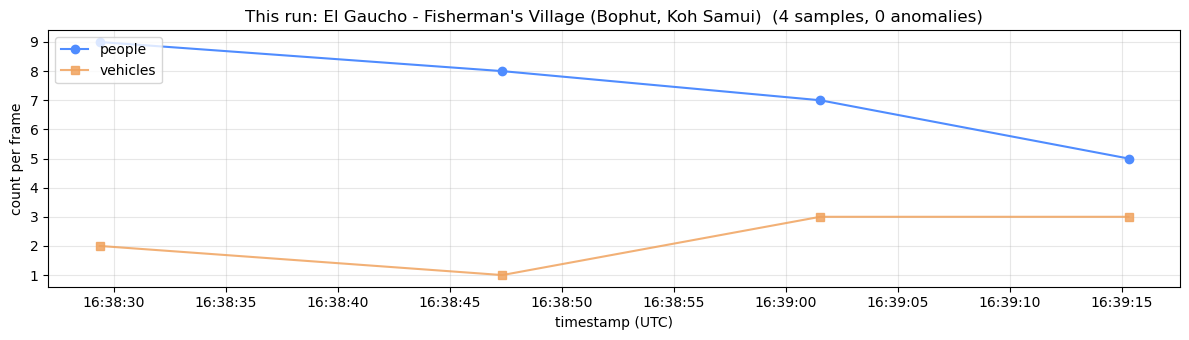


For the live single-camera dashboard:
  in-notebook: run the cell in Section 7 above (embedded IFrame)
  standalone : python serve.py        (from the project root)
  open       : http://localhost:8000  (opens automatically)


In [19]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from datetime import datetime, timezone

    print(f"Notebook run finished at {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"Live camera for this run: {cam['name']}")
    print("=" * 78)

    # ---- aggregate anomalies into one DataFrame ----
    anom_frames = []
    if "df" in dir() and isinstance(df, pd.DataFrame) and not df.empty and "anomaly" in df.columns:
        a = df[df["anomaly"] == True].copy()
        if not a.empty:
            a["cam"] = cam["name"]
            anom_frames.append(a[["ts", "cam", "person", "vehicles"]])
    anom = pd.concat(anom_frames, ignore_index=True) if anom_frames else \
           pd.DataFrame(columns=["ts", "cam", "person", "vehicles"])

    if len(anom):
        print(f"\nAnomalies flagged (robust rolling z > 3.5): {len(anom)}")
        print(anom.to_string(index=False))
    else:
        print("\nAnomalies flagged: 0")
        print("(Too few samples for the z-score window to trip, or the scene was steady.)")

    # ---- re-ID rollup ----
    if "reid" in dir():
        stats = reid.stats(CAM_ID)
        print("\n" + "-" * 78)
        print(f"Re-identification - {cam['name']}")
        print(f"  total unique entities   : {stats['total_unique']}")
        print(f"  total sightings         : {stats['total_sightings']}")
        for cls, s in stats["per_class"].items():
            print(f"    {cls:10s}  unique={s['unique']}  "
                  f"sightings={s['total_sightings']}  "
                  f"regulars(>=3)={s['regulars']}")
        regulars = reid.top_regulars(CAM_ID, n=5)
        if regulars:
            print("  top returning:")
            for r in regulars:
                print(f"    #{r['entity_id']:>4}  {r['cls']:8s}  "
                      f"sightings={r['sightings']}  last_seen={r['last_seen']}")

    # ---- always-on visual: footfall over this run + anomalies overlaid ----
    # Build the plot only when we have data; do NOT call ax.legend() on an empty
    # axes (that produces the "No artists with labels found" warning).
    if "df" in dir() and isinstance(df, pd.DataFrame) and not df.empty:
        ts = pd.to_datetime(df["ts"])
        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(ts, df["person"],   marker="o", color="#4f8cff", label="people")
        ax.plot(ts, df["vehicles"], marker="s", color="#f0a35e", label="vehicles", alpha=0.85)
        if len(anom):
            ax.scatter(pd.to_datetime(anom["ts"]), anom["person"],
                       s=160, color="#ef4444", marker="X", zorder=5, label="anomaly")
        ax.set_title(f"This run: {cam['name']}  ({len(df)} samples, {len(anom)} anomalies)")
        ax.set_ylabel("count per frame"); ax.set_xlabel("timestamp (UTC)")
        ax.legend(loc="upper left"); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    print("\n" + "=" * 78)
    print("For the live single-camera dashboard:")
    print("  in-notebook: run the cell in Section 7 above (embedded IFrame)")
    print("  standalone : python serve.py        (from the project root)")
    print("  open       : http://localhost:8000  (opens automatically)")

except Exception as e:
    print(f"summary cell stopped early: {type(e).__name__}: {e}")


## 10. Accuracy calibration - how good are the counts, really?

The dashboard is only as trustworthy as YOLO is on THESE cameras. This section
measures it: capture frames from the 4 live grid cameras, run the detector at
two input sizes (640 = old default, 960 = the collector's current default),
then count people/vehicles yourself and get MAE + bias per camera and per size.

Workflow (all local, ~10 minutes of counting):
1. **10a** captures frames + predictions into `data/calibration/`;
2. **10b** shows each frame - you type the true `people,vehicles`;
3. **10c** prints the accuracy table and a conf/imgsz recommendation.

Feed the result back into the pipeline: the winning `imgsz` goes to the
collector's `--imgsz`, and a camera with a systematic bias gets a `"conf"`
override in `app/cameras.py` (bias < 0 -> lower conf, bias > 0 -> raise it).

In [ ]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    # No interactive picker choice was applied. Instead of throwing an
    # opaque exception that pauses the notebook, print a clear warning
    # and default to the first camera in the catalog so the operator
    # can Restart & Run All top-to-bottom without hand-clicking every
    # cell. The verify cell above STILL lets them pick a different one
    # and re-run from there.
    try:
        _default_id = next(iter(CAMERAS))
    except (NameError, StopIteration):
        raise RuntimeError('CAMERAS catalog not loaded - run the earlier setup cells first')
    SELECTED_CAM_ID = _default_id
    SELECTED_CAM = CAMERAS[_default_id]
    SELECTED_CAMS = [_default_id]
    SELECTED_CAMS_APPLIED = True
    print(f'NOTE: no picker choice applied - defaulting to {_default_id} '
          f'("{SELECTED_CAM["name"]}"). To pick a different camera, run '
          f'the interactive picker cell above and re-run this cell.')
# --- 10a. Capture calibration frames + predictions (run once, ~1-2 min) ---
import json as _json
from app.detect_core import grab_burst, detect_with_boxes, annotate

CALIB_DIR = DATA_DIR / 'calibration'; CALIB_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_PER_CAM = 6          # 4 cams x 6 frames = 24 to label (aim for 20-30)
IMG_SIZES = (640, 960)      # old default vs the collector's current default
CALIB_CONF = 0.30           # keep in sync with the collector's --conf

samples = []
for cam_id in SELECTED_CAMS:
    cam = CAMERAS[cam_id]
    try:
        url = resolve_stream(cam)
    except Exception as e:
        print(f'{cam_id}: resolve failed ({e}) - skipping'); continue
    got = 0
    for k in range(FRAMES_PER_CAM):
        frames = grab_burst(url, n=1)
        if not frames:
            print(f'{cam_id}: frame {k} MISS'); continue
        frame = frames[0]
        stem = f'{cam_id}_{k:02d}'
        cv2.imwrite(str(CALIB_DIR / f'{stem}.jpg'), frame)
        entry = {'stem': stem, 'cam_id': cam_id}
        for size in IMG_SIZES:
            counts, _ = detect_with_boxes(model, frame, conf=CALIB_CONF, imgsz=size)
            entry[f'person_{size}']   = counts['person']
            entry[f'vehicles_{size}'] = counts['vehicles']
        cv2.imwrite(str(CALIB_DIR / f'{stem}_annotated.jpg'),
                    annotate(model, frame, conf=CALIB_CONF, imgsz=max(IMG_SIZES)))
        samples.append(entry); got += 1
        time.sleep(2)   # let the live stream move on a little between captures
    print(f'{cam_id}: captured {got} frames')

(CALIB_DIR / 'predictions.json').write_text(_json.dumps(samples, indent=2))
print(f'{len(samples)} frames -> {CALIB_DIR}')

plates: easyocr Reader loaded for 'th'
detect: OpenVINO engine rejected imgsz=960 - torch fallback (C:\Users\OR\Downloads\לימודים\Data Science\Project\Real_Time_CV_Object_Tracking_YOLO26\yolo26x.pt) for non-native sizes
plates: easyocr Reader loaded for 'ar'
plates: easyocr Reader loaded for 'ja'


C:\Users\OR\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# INTERACTIVE cell - it asks YOU to type counts, so it must never run
# under Run All (it would stall the whole run waiting for keyboard
# input). Set RUN_LABELING = True and re-run this cell when you are
# ready to label; leave it False for hands-off runs.
RUN_LABELING = globals().get('RUN_LABELING', False)
if not RUN_LABELING:
    print('Labeling skipped (RUN_LABELING is False).')
    print('When you want to label: set RUN_LABELING = True in this cell')
    print('and run it again - it will show each frame and ask for the')
    print('true people,vehicles counts.')
else:
    # --- 10b. Label: look at each frame, type the true counts ---
    # The annotated image shows what the model saw at imgsz=960. Count what YOU
    # see: people, then vehicles (cars+buses+trucks+motorbikes+bicycles), and type
    # `people,vehicles` (e.g. `7,3`). Enter = skip frame, q = stop early.
    import json as _json

    samples = _json.loads((CALIB_DIR / 'predictions.json').read_text())
    labeled = []
    for s in samples:
        img = cv2.cvtColor(cv2.imread(str(CALIB_DIR / f"{s['stem']}_annotated.jpg")),
                           cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 7)); plt.imshow(img); plt.axis('off')
        plt.title(f"{s['stem']}  |  model@960: person={s['person_960']} "
                  f"vehicles={s['vehicles_960']}")
        plt.show()
        raw = input(f"{s['stem']} true 'people,vehicles' (Enter=skip, q=stop): ").strip()
        if raw.lower() == 'q':
            break
        if not raw:
            continue
        try:
            p_true, v_true = (int(x) for x in raw.replace(' ', '').split(','))
        except ValueError:
            print('  could not parse - skipped'); continue
        labeled.append({**s, 'person_true': p_true, 'vehicles_true': v_true})

    (CALIB_DIR / 'labeled.json').write_text(_json.dumps(labeled, indent=2))
    print(f'labeled {len(labeled)} frames -> {CALIB_DIR / "labeled.json"}')

In [ ]:
## --- 10c. Accuracy report: MAE + bias per input size and per camera ---
# Section 10 is OPTIONAL QA (measures how accurate YOLO's counts are on
# YOUR cameras). It needs YOU to type true counts in cell 10b. If you
# haven't done that yet, this cell just prints a note and does nothing -
# it is NOT an error and does not interrupt Run All.
import json as _json

_labeled_path = CALIB_DIR / 'labeled.json'

if not _labeled_path.exists():
    print('Section 10c skipped: no calibration labels on disk yet.')
    print()
    print('This is expected on a fresh run - section 10 is optional QA.')
    print('If you WANT to measure accuracy on your camera:')
    print('  1) Run cell 10a (captures 6 frames from the picked camera).')
    print('  2) Set RUN_LABELING = True in cell 10b, run it, and type the')
    print('     true (people, vehicles) counts for each frame it shows you.')
    print('  3) Re-run this cell.')
    print()
    print('If you only want the live dashboard (section 7), you can skip')
    print('section 10 entirely - the dashboard does not need it.')
else:
    try:
        rows = _json.loads(_labeled_path.read_text())
    except (OSError, ValueError) as _e:
        print(f'Section 10c skipped: {_labeled_path.name} exists but is unreadable ({_e}).')
        print('Delete it and re-run cells 10a and 10b to regenerate.')
        rows = None

    if not rows:
        print('Section 10c skipped: no labeled rows in labeled.json yet.')
        print('Re-run cell 10b with RUN_LABELING = True and enter at least one label.')
    else:
        cal = pd.DataFrame(rows)
        overall = []
        for size in IMG_SIZES:
            for metric in ('person', 'vehicles'):
                err = cal[f'{metric}_{size}'] - cal[f'{metric}_true']
                overall.append({'size': size, 'metric': metric,
                                'MAE': err.abs().mean(),
                                'bias': err.mean(),
                                'n_frames': len(cal)})
        print('=== Overall accuracy per input size ===')
        print(pd.DataFrame(overall).to_string(index=False))

        if 'cam_id' in cal.columns:
            per_cam = []
            for size in IMG_SIZES:
                for metric in ('person', 'vehicles'):
                    for cid, sub in cal.groupby('cam_id'):
                        err = sub[f'{metric}_{size}'] - sub[f'{metric}_true']
                        per_cam.append({'cam': cid, 'size': size, 'metric': metric,
                                        'MAE': err.abs().mean(),
                                        'bias': err.mean(),
                                        'n': len(sub)})
            print()
            print('=== Per-camera accuracy ===')
            print(pd.DataFrame(per_cam).to_string(index=False))
